In [28]:
import numpy as np
import pandas as pd
import MDAnalysis as mda
import matplotlib.pyplot as plt

In [29]:
"""
Step1: Data loading from the trajectory file
"""
u=mda.Universe("final_nvt_equilibrated.data", "Water.lammpstrj", format="LAMMPSDUMP", lengthunit="A", timeunit="fs", dt=2, atom_style="id mol type q x y z")
Water=u.atoms
n_atoms=len(Water)
n_water=int(n_atoms/3)
posi=[]

for i, ts in enumerate(u.trajectory):
    posi.append(Water.positions)

pos=np.array(posi)
print(pos.shape)
n_frames=len(pos)
box=19.711200000000002

Oxygen=np.zeros((n_frames, n_water, 3))
Hydrogen1=np.zeros((n_frames, n_water, 3))
Hydrogen2=np.zeros((n_frames, n_water, 3))

for i in range(pos.shape[0]):
    Oxygen[i]=pos[i, 0::3, :]%box
    Hydrogen1[i]=pos[i, 1::3, :]%box
    Hydrogen2[i]=pos[i, 2::3, :]%box

(7501, 768, 3)


In [30]:
"""
Step2: Important parameters for calculations
"""

n_skip=int(0.01*n_frames)                               #Let's skip first 1% of the frames for equilibration
print(n_skip)
dt=0.5                                                  #Time step in fs
dump_freq=20                                            #Dump frequency in frames
time_bw_frames=dt*dump_freq
n_blocks=5
n_framesperblock=n_frames//n_blocks
traj_frac=0.4
maxlagtime=n_framesperblock*traj_frac*time_bw_frames
n_framesmaxlag=int(maxlagtime/time_bw_frames)
n_initial=int(n_framesperblock-n_framesmaxlag)         #Possible values of starting times

def MIC(dirn):
    dir=dirn-np.round(dirn/box)*box
    return dir

75


Block0 started
Block1 started
Block2 started
Block3 started
Block4 started


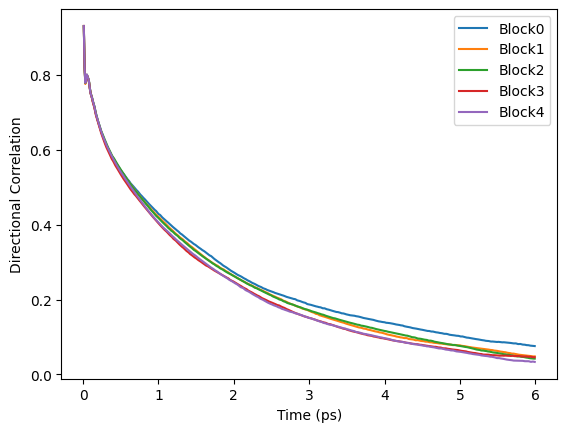

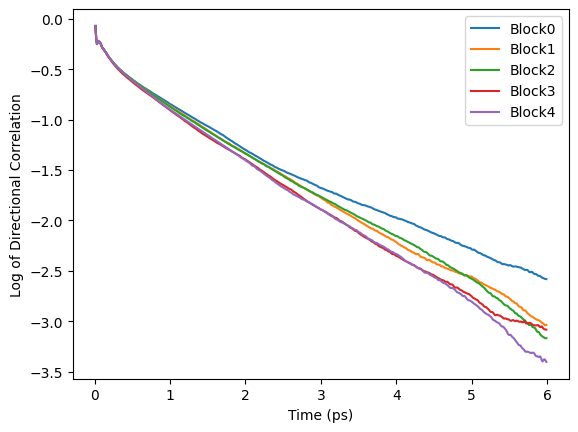

In [35]:
"""
Step3: Actual Calculations, finding the correlations for every block, and then doing the block averages
"""
corr_dir=np.zeros((n_framesmaxlag, n_blocks))
time=np.arange(1, n_framesmaxlag)*(time_bw_frames/1000)           #Time in ps

for i in range(n_blocks):
    starting=i*n_framesperblock
    print(f"Block{i} started")
    for j in range(n_initial):
        ind_in=starting+j                            #This is the starting time
        
        #The directions at t=0 (starting time), for all waters (size=n_atoms*3)
        oh1_in=MIC(Hydrogen1[ind_in]-Oxygen[ind_in])
        oh2_in=MIC(Hydrogen2[ind_in]-Oxygen[ind_in])
        mu_in=0.5*(oh1_in+oh2_in)
        mu_in_mag=np.linalg.norm(mu_in, axis=1)

        for k in range(n_framesmaxlag):
            ind_fi=ind_in+k
            oh1_fi=MIC(Hydrogen1[ind_fi]-Oxygen[ind_fi])
            oh2_fi=MIC(Hydrogen2[ind_fi]-Oxygen[ind_fi])
            mu_fi=0.5*(oh1_fi+oh2_fi)
            mu_fi_mag=np.linalg.norm(mu_fi, axis=1)

            #cosine of angle between a water's direction at t=initial time and some final time, for all water molecules
            cos_theta=np.sum(mu_fi*mu_in, axis=1)
            cos_theta=cos_theta/(mu_in_mag*mu_fi_mag)

            #The <P2[cos_theta]> now
            P2=0.5*(3*cos_theta**2-1)
            corr_dir[k, i]+=np.mean(P2)/n_initial

corr_dir=corr_dir[1:]

for i in range(n_blocks):
    plt.plot(time, corr_dir[:, i], label=f"Block{i}")
plt.xlabel("Time (ps)")
plt.ylabel("Directional Correlation")
plt.legend()
plt.show()

log_corr=np.log(corr_dir)
for i in range(n_blocks):
    plt.plot(time, log_corr[:, i], label=f"Block{i}")
plt.xlabel("Time (ps)")
plt.ylabel("Log of Directional Correlation")
plt.legend()
plt.show()

In [34]:
"""
Step4: Finding tau_n, using 2 techniques, fitting and integration
The semilog plot gives an idea that the first 10% and last 25% of the data can be left, so use that for fitting
"""

#Fitting
corr_fit=log_corr[int(0.1*len(log_corr)):int(0.75*len(log_corr))]
time_fit=time[int(0.1*len(time)):int(0.75*len(time))]
slope, intercept=np.polyfit(time_fit, corr_fit, 1)
tau=-1/slope
print(tau)

#Integration Method
Integral=np.zeros(n_blocks)
for i in range(n_blocks):
    Integral[i]=np.trapezoid(corr_dir[:, i], time)
print(Integral)

[2.66835465 2.22336022 2.33744253 2.08743869 2.08019739]
[1.50417139 1.39781628 1.4009779  1.31484798 1.31128274]
